In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('insurance.csv')

In [4]:
print(df)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


In [6]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

No Null Values

In [9]:
df.duplicated().sum()

np.int64(1)

One duplicate value lets drop it 

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [21]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


Here,
here all our features are perfectly symmetrical only the target column is right skewed which make no sence

<Axes: >

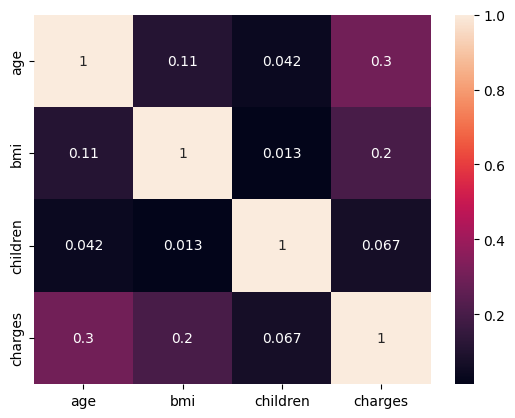

In [27]:
# lets check the correlation 
df1=df.corr(numeric_only=True)
sns.heatmap(df1,annot=True)

here we can see
the bmi and age is positively correlated to the charges 
but still age has higher corelation with charges

<Axes: xlabel='smoker', ylabel='charges'>

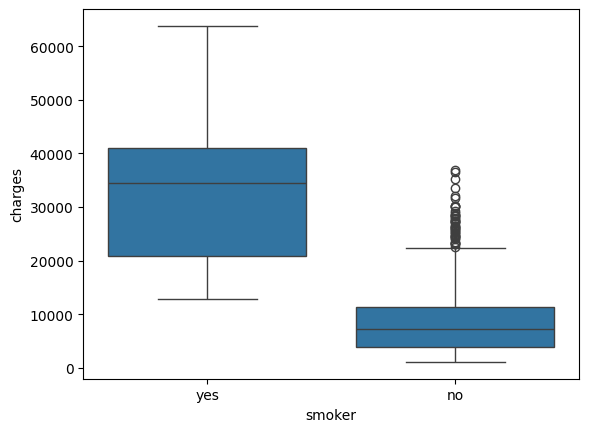

In [28]:
#lets see for categorical features
sns.boxplot(x="smoker", y="charges", data=df)

as we can see the smokers (yes) their median charges is around 35k and maximum is 60k and min is 12k 
but the smokets (No) their median charges is around 8k and maximum is 22k and have some outliers 
means it is clear that smoker is impactful for the target (charges)

<Axes: xlabel='sex', ylabel='charges'>

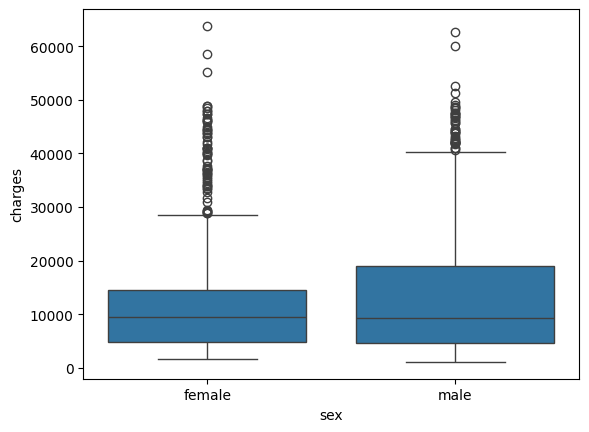

In [29]:
sns.boxplot(x=df['sex'],y=df['charges'])

here distribution for sex is same for both gender only the difference is that male have some more charges and in general also this is true
so gender is not that much impactfull

<Axes: xlabel='region', ylabel='charges'>

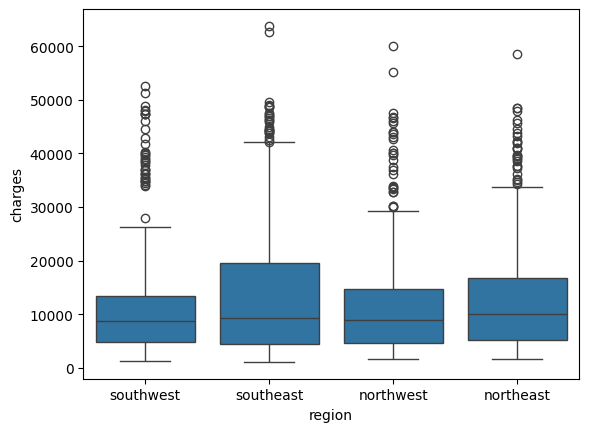

In [30]:
sns.boxplot(x=df['region'],y=df['charges'])

here also same not that much difference in the charges of region also so it is also not that much impactfull

<Axes: xlabel='charges', ylabel='Count'>

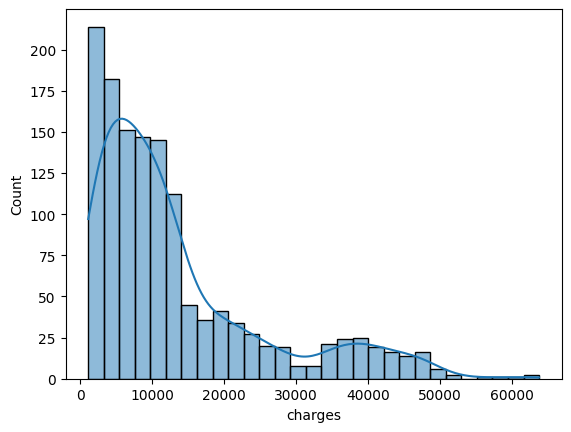

In [33]:
# lets check the distribution of the charges 
sns.histplot(df['charges'],kde=True)

here we can see that the distribution is right skewed means the less number of people pay the less amount of charges